In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [ ]:
# Load cleaned Data from phase 1
df = pd.read_csv('Titanic.csv')

In [ ]:
# One-hot encode nominal categories; drop_first prevents multicollinearity. Slide Number 117
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
print(f'Columns after One Hot Encoding: {df.columns.tolist()}')


Columns after One Hot Encoding: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


In [ ]:
# Ordinal encode Pclass to preserve class hierarchy (1st > 2nd > 3rd)
df['class_rank'] = df['Pclass'].map({1: 3, 2: 2, 3: 1})
print(df[['Pclass', 'class_rank']].drop_duplicates().sort_values('Pclass'))

   Pclass  class_rank
1       1           3
9       2           2
0       3           1


In [ ]:
# Standardize Age/Fare to mean=0, std=1 for distance-based models. Slide Number 123
scaler = StandardScaler()
df[['Age_scaled', 'Fare_scaled']] = scaler.fit_transform(df[['Age', 'Fare']])
print(df[['Age', 'Age_scaled', 'Fare', 'Fare_scaled']].head())

    Age  Age_scaled     Fare  Fare_scaled
0  22.0   -0.565736   7.2500    -0.564109
1  38.0    0.663861  71.2833     0.942548
2  26.0   -0.258337   7.9250    -0.548227
3  35.0    0.433312  53.1000     0.514708
4  35.0    0.433312   8.0500    -0.545285


In [ ]:
# FamilySize captures solo vs family traveler survival patterns
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Fare per person controls for family ticket purchases and also using safe division.
df['Fare_Per_Person'] = df['Fare'] / df['FamilySize'].replace(0, np.nan)
df['Fare_Per_Person'] = df['Fare_Per_Person'].fillna(0)

print(df[['SibSp', 'Parch', 'FamilySize', 'Fare', 'Fare_Per_Person']].head(8))

   SibSp  Parch  FamilySize     Fare  Fare_Per_Person
0      1      0           2   7.2500          3.62500
1      1      0           2  71.2833         35.64165
2      0      0           1   7.9250          7.92500
3      1      0           2  53.1000         26.55000
4      0      0           1   8.0500          8.05000
5      0      0           1   8.4583          8.45830
6      0      0           1  51.8625         51.86250
7      3      1           5  21.0750          4.21500


In [ ]:
# Interaction term captures combined class-age survival effects
df['class_age_interaction'] = df['class_rank'] * df['Age_scaled']

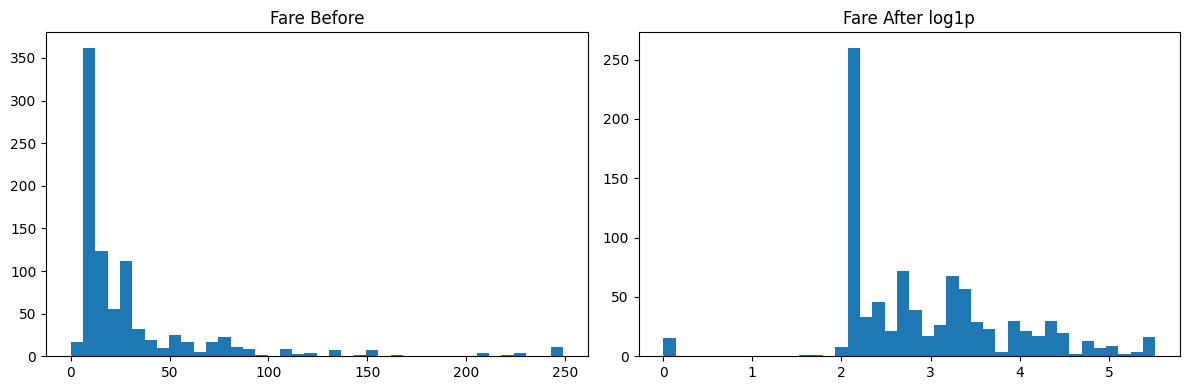

In [ ]:
# Log transform reduces right skew in Fare distribution. Slide Number 134
df['Fare_log'] = np.log1p(df['Fare'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Fare'], bins=40)
axes[0].set_title('Fare Before')

axes[1].hist(df['Fare_log'], bins=40)
axes[1].set_title('Fare After log1p')
plt.tight_layout()
plt.show()

In [ ]:
# bin age into life stages based on survival priorities .Slide Number 131
bins = [0, 12, 17, 59, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior']
df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

In [ ]:
# Remove features with correlation >0.95 to prevent multicollinearity
df_numeric = df.select_dtypes(include=['number'])
# I got stuck in this step bacause I tried to do corr() on the entire Data, solved it using Copilot by making the df_numeric variable.
corr_matrix = df_numeric.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print(to_drop)
df = df.drop(columns=to_drop)

['class_rank', 'Age_scaled', 'Fare_scaled']
